<img src="logo_UNSAM.jpg" align="right" width="120" /> 
<br><br><br><br>
<div style="text-align: center;">

### Analisis y procesamiento de señales 1C 2026
# Trabajo Práctico Nº7

### Melanie amicucci

<br>
</div>

# Introducción
En este trabajo se estudia el filtrado digital de una señal electrocardiográfica con el objetivo de reducir el ruido presente en el ECG sin tener modificaciones importantes.

Para esto se diseña una plantilla de filtro pasa banda, conservando principalmente las componentes de la señal entre 0,5 Hz y 35 Hz. Las frecuencias muy bajas se atenúan para reducir el desplazamiento de la línea de base, mientras que las frecuencias altas se eliminan para disminuir el ruido muscular y otras interferencias.

Se comparan distintos métodos de diseño de filtros digitales: un filtro IIR Butterworth y filtros FIR diseñados mediante ventana rectangular, cuadrados mínimos y Parks-McClellan/Remez. Luego, cada filtro se aplica sobre la señal ECG y se analiza su respuesta tanto en frecuencia como en el dominio temporal.


### Implementación del codigo 
En este bloque se definen los parámetros principales de la plantilla de diseño del filtro. Se fija la frecuencia de muestreo de la señal y se establecen las condiciones que debe cumplir el filtro: una atenuación máxima de 1 dB en la banda de paso y una atenuación mínima de 40 dB en las bandas de rechazo. Además, se determinan los límites de frecuencia del filtro pasa banda, buscando conservar las componentes útiles del ECG entre 0,5 Hz y 35 Hz, y atenuar las componentes de muy baja y alta frecuencia asociadas al ruido.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig
import scipy.io as sio


#%% Parametros del filtro

fs = 1000      # Frecuencia de muestreo en Hz

gpass = 1      # Atenuacion maxima permitida en banda de paso [dB]
gstop = 40     # Atenuacion minima requerida en banda de stop [dB]

# Plantilla pasa banda
ws1 = 0.1     # Banda de stop baja
wp1 = 0.5      # Inicio banda de paso
wp2 = 35     # Fin banda de paso
ws2 = 38     # Banda de stop alta

wp = [wp1, wp2]
ws = [ws1, ws2]


### FILTRO BUTTERWORTH
se diseña el filtro IIR Butterworth a partir de la plantilla definida anteriormente. Se utiliza la función iirdesign, indicando las bandas de paso y rechazo, junto con las atenuaciones requeridas. El filtro se obtiene en formato SOS para mejorar la estabilidad numérica.

In [8]:
#%% Diseno del filtro Butterworth IIR
sos_but = sig.iirdesign(
    wp,
    ws,
    gpass/2,
    gstop/2,
    fs=fs,
    analog=False,
    ftype='butter',
    output='sos'
)
ww = np.concatenate([
    np.logspace(start=-2, stop=0.1, num=500),
    np.linspace(start=1.26, stop=35, num=200),
    np.logspace(start=1.55, stop=1.65, num=300),
    np.linspace(start=46, stop=fs/2, num=50)
])

ww = np.unique(ww)
ww = ww[ww <= fs/2]



## FILTROS FIR 
### Método de ventana 
Se define la cantidad de coeficientes del filtro y la ganancia, de manera que el filtro se comporte como pasa banda. Luego, con `firwin2`, se calculan los coeficientes del filtro y, mediante `freqz`, se obtiene su respuesta en frecuencia. Finalmente, se calcula el módulo en dB para poder compararlo con la plantilla de diseño.


In [9]:

#%% Diseno de FIR con ventana rectangular

numtaps = 2500

gains = np.array([0, 0, 1, 1, 0, 0])

b_win = sig.firwin2(
    numtaps,
    freq=np.array([0., ws1, wp1, wp2, ws2, fs/2]),
    gain=gains,
    window='boxcar',
    fs=fs
)

# Respuesta en frecuencia del FIR
w, h = sig.freqz(b_win, worN=ww, fs=fs)

modulo_db = 20 * np.log10(np.abs(h) + 1e-12)


Gráfico

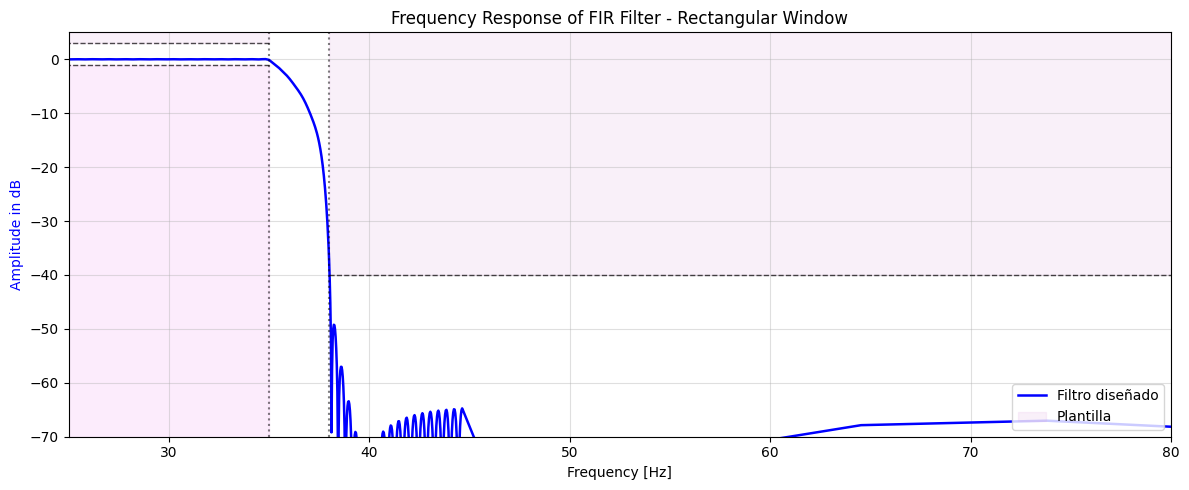

In [25]:
fig, ax1 = plt.subplots(figsize=(12, 5), tight_layout=True)

ax1.set_title("Frequency Response of FIR Filter - Rectangular Window")

ax1.plot(w, modulo_db, 'b', linewidth=1.8, label='Filtro diseñado')

piso_grafico = -125
techo_grafico = 5

# Banda de parada baja
ax1.fill_between(
    [0, ws1],
    -gstop,
    techo_grafico,
    color='plum',
    alpha=0.15,
    label='Plantilla'
)

ax1.plot(
    [0, ws1],
    [-gstop, -gstop],
    'k--',
    linewidth=1,
    alpha=0.7
)

# Banda de paso
ax1.fill_between(
    [wp1, wp2],
    piso_grafico,
    -gpass,
    color='violet',
    alpha=0.15
)

ax1.plot(
    [wp1, wp2],
    [-gpass, -gpass],
    'k--',
    linewidth=1,
    alpha=0.7
)

# Zona superior banda de paso
ax1.fill_between(
    [wp1, wp2],
    3,
    techo_grafico,
    color='plum',
    alpha=0.15
)

ax1.plot( [wp1, wp2],[3, 3],'k--', linewidth=1,alpha=0.7)

# Banda de parada alta
ax1.fill_between([ws2, fs/2], -gstop, techo_grafico,color='plum',alpha=0.15)

ax1.plot( [ws2, fs/2],[-gstop, -gstop],'k--', linewidth=1,alpha=0.7)

# Lineas verticales
ax1.axvline(ws1, color='k', linestyle=':', alpha=0.5)
ax1.axvline(wp1, color='k', linestyle=':', alpha=0.5)
ax1.axvline(wp2, color='k', linestyle=':', alpha=0.5)
ax1.axvline(ws2, color='k', linestyle=':', alpha=0.5)

ax1.set_ylabel("Amplitude in dB", color='b')
ax1.set_xlabel("Frequency [Hz]")
ax1.set_xlim(25, 80)   
ax1.set_ylim(-70, 5)     
ax1.grid(True, which='both', linestyle='-', alpha=0.4)
ax1.legend(loc='lower right')

plt.show()


### Método de cuadrados minimos

In [10]:
#%% FILTRO FIR CON CUADRADOS MINIMOS 
ws1c = 0.3    # Banda de stop baja
wp1c = 0.5      # Inicio banda de paso
wp2c = 35       # Fin banda de paso
ws2c = 37       # Banda de stop alta
    
numtapsc = 1825
    
weight = np.array([2,1,1])
b_cuadradosmin = sig.firls (numtapsc , bands =np.array([0., ws1c, wp1c, wp2c, ws2c, fs/2]), desired=[0, 0, 1, 1, 0, 0], weight = weight, fs = fs ) 
    # Respuesta en frecuencia del FIR
wc, hc = sig.freqz(b_cuadradosmin, worN=ww, fs=fs)

modulo_dbc = 20 * np.log10(np.abs(hc) + 1e-12)



Gráfico 

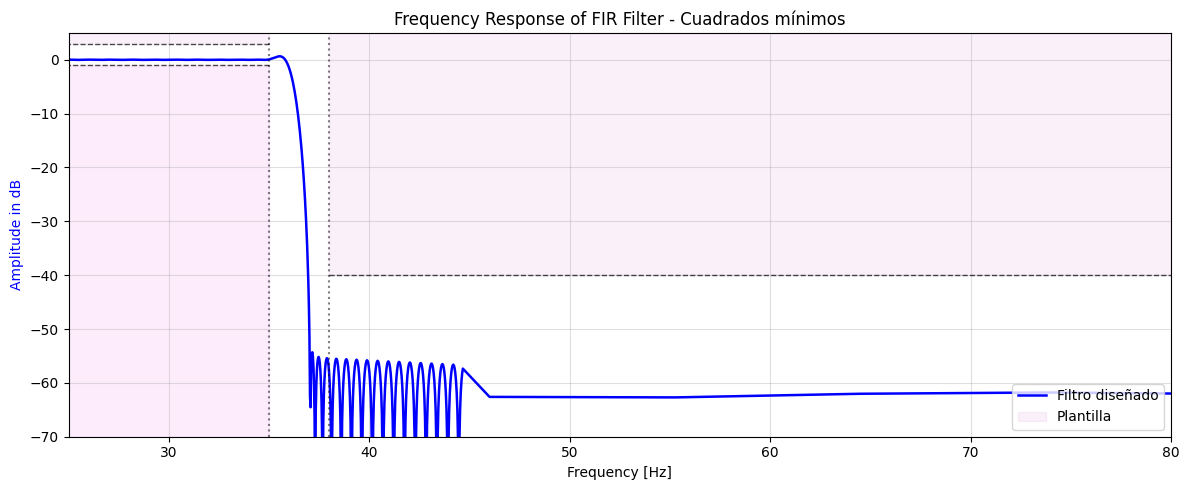

In [26]:
fig, ax1 = plt.subplots(figsize=(12, 5), tight_layout=True)

ax1.set_title("Frequency Response of FIR Filter - Cuadrados mínimos")

ax1.plot(wc, modulo_dbc, 'b', linewidth=1.8, label='Filtro diseñado')

piso_grafico = -125
techo_grafico = 5

    # Banda de parada baja
ax1.fill_between(
    [0, ws1],
    -gstop,
    techo_grafico,
    color='plum',
    alpha=0.15,
    label='Plantilla'
    )

ax1.plot(
      [0, ws1],
        [-gstop, -gstop],
        'k--',
        linewidth=1,
        alpha=0.7
    )

    # Banda de paso
ax1.fill_between(
        [wp1, wp2],
        piso_grafico,
        -gpass,
        color='violet',
        alpha=0.15
    )

ax1.plot(
        [wp1, wp2],
        [-gpass, -gpass],
        'k--',
        linewidth=1,
        alpha=0.7
    )

    # Zona superior banda de paso
ax1.fill_between(
        [wp1, wp2],
        3,
        techo_grafico,
        color='plum',
        alpha=0.15
    )

ax1.plot(
        [wp1, wp2],
        [3, 3],
        'k--',
        linewidth=1,
        alpha=0.7
    )

    # Banda de parada alta
ax1.fill_between(
        [ws2, fs/2],
        -gstop,
        techo_grafico,
        color='plum',
        alpha=0.15
    )

ax1.plot(
        [ws2, fs/2],
        [-gstop, -gstop],
        'k--',
        linewidth=1,
        alpha=0.7
    )

    # Lineas verticales
ax1.axvline(ws1, color='k', linestyle=':', alpha=0.5)
ax1.axvline(wp1, color='k', linestyle=':', alpha=0.5)
ax1.axvline(wp2, color='k', linestyle=':', alpha=0.5)
ax1.axvline(ws2, color='k', linestyle=':', alpha=0.5)

ax1.set_ylabel("Amplitude in dB", color='b')
ax1.set_xlabel("Frequency [Hz]")
ax1.set_xlim(25, 80)   
ax1.set_ylim(-70, 5)  
ax1.grid(True, which='both', linestyle='-', alpha=0.4)
ax1.legend(loc='lower right')

plt.show()


### Método de Mc Clellan-Remez

In [19]:
ws1r = 0.1    # Banda de stop baja
wp1r = 0.5       # Inicio banda de paso
wp2r = 35        # Fin banda de paso
ws2r = 36        # Banda de stop alta

numtapsr = 2001

weightr = np.array([2, 1, 1])

b_remez = sig.remez(numtapsr,bands=np.array([0., ws1r, wp1r, wp2r, ws2r, fs/2]),desired=[0, 1, 0],weight=weightr,maxiter=25,grid_density=16,fs=fs
)

# Respuesta en frecuencia del FIR
wr, hr = sig.freqz(b_remez, worN=ww, fs=fs)

modulo_dbr = 20 * np.log10(np.abs(hr) + 1e-12)



Gráfico de Remez 

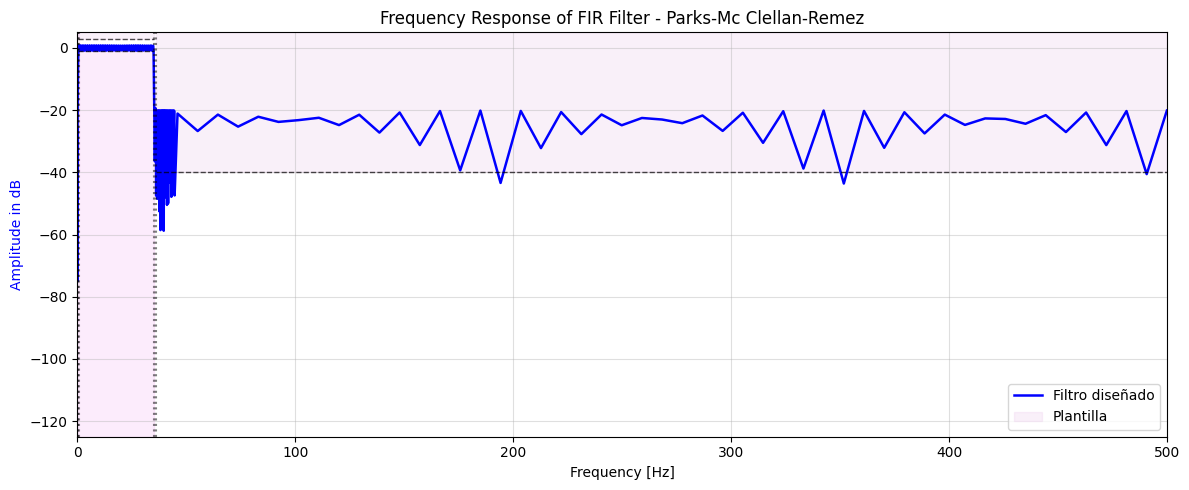

In [18]:
fig, ax1 = plt.subplots(figsize=(12, 5), tight_layout=True)

ax1.set_title("Frequency Response of FIR Filter - Parks-Mc Clellan-Remez")

ax1.plot(wr, modulo_dbr, 'b', linewidth=1.8, label='Filtro diseñado')

piso_grafico = -125
techo_grafico = 5

# Banda de parada baja
ax1.fill_between([0, ws1r],-gstop,techo_grafico, color='plum',alpha=0.15,label='Plantilla')

ax1.plot([0, ws1r], [-gstop, -gstop],'k--', linewidth=1, alpha=0.7)

# Banda de paso
ax1.fill_between([wp1r, wp2r],piso_grafico,-gpass,color='violet',alpha=0.15)

ax1.plot([wp1r, wp2r],[-gpass, -gpass],'k--', linewidth=1, alpha=0.7)

# Zona superior banda de paso
ax1.fill_between([wp1r, wp2r], 3,techo_grafico,color='plum',alpha=0.15)

ax1.plot([wp1r, wp2r],[3, 3],'k--',linewidth=1,alpha=0.7)

# Banda de parada alta
ax1.fill_between([ws2r, fs/2], -gstop,techo_grafico,color='plum',alpha=0.15)

ax1.plot([ws2r, fs/2],[-gstop, -gstop],'k--', linewidth=1,alpha=0.7)

# Lineas verticales
ax1.axvline(ws1r, color='k', linestyle=':', alpha=0.5)
ax1.axvline(wp1r, color='k', linestyle=':', alpha=0.5)
ax1.axvline(wp2r, color='k', linestyle=':', alpha=0.5)
ax1.axvline(ws2r, color='k', linestyle=':', alpha=0.5)

ax1.set_ylabel("Amplitude in dB", color='b')
ax1.set_xlabel("Frequency [Hz]")
ax1.set_xlim(0, fs/2)
ax1.set_ylim([piso_grafico, techo_grafico])
ax1.grid(True, which='both', linestyle='-', alpha=0.4)
ax1.legend(loc='lower right')

plt.show()


### Analisis
Toda la señal queda en el filtro, hay algun error en este código.

# Análisis temporal del ECG

En esta sección se carga la señal electrocardiográfica desde el archivo `ECG_TP4.mat`. A partir de este archivo se obtiene el registro `ecg_lead`, que contiene el ECG muestreado a una frecuencia de 1000 Hz. Luego se calcula la cantidad total de muestras para conocer la extensión temporal de la señal y poder seleccionar distintas regiones de análisis.

Una vez cargada la señal, se aplican los filtros diseñados previamente.

Finalmente, se seleccionan distintas regiones de interés de la señal ECG. Algunas corresponden a zonas donde se observa mayor presencia de ruido, y otras a zonas más limpias. El objetivo de estos gráficos es comparar visualmente la señal original con las señales filtradas, verificando si los filtros reducen las interferencias sin modificar de manera importante la forma de los latidos.



INFORMACION ECG
--------------------------------
Cantidad de muestras: 1129116
Frecuencia de muestreo ECG: 1000 Hz
--------------------------------


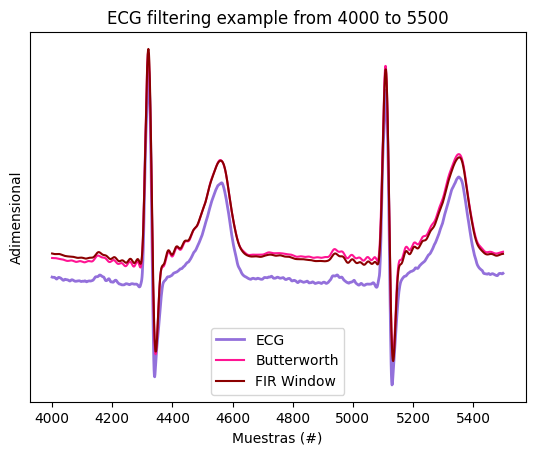

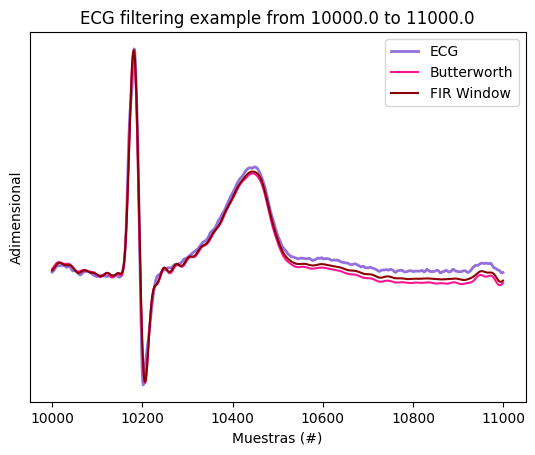

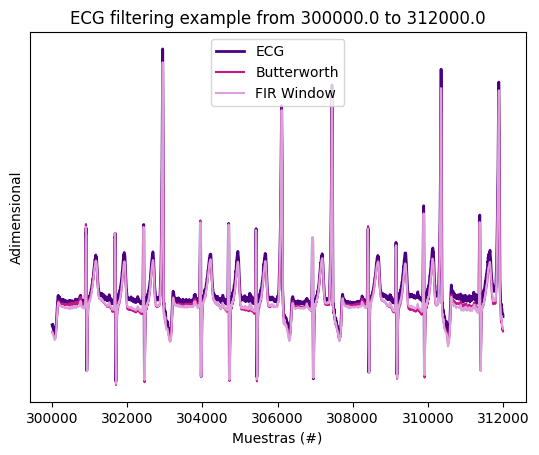

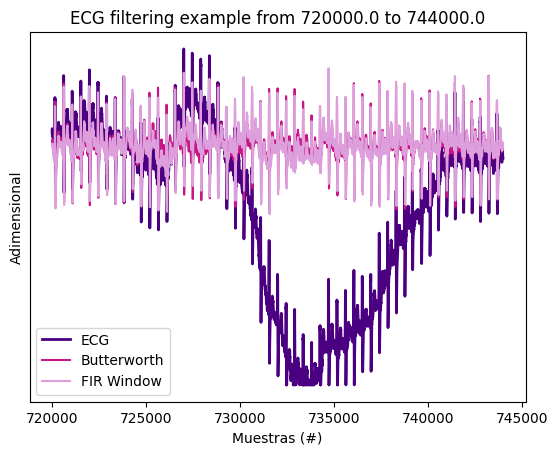

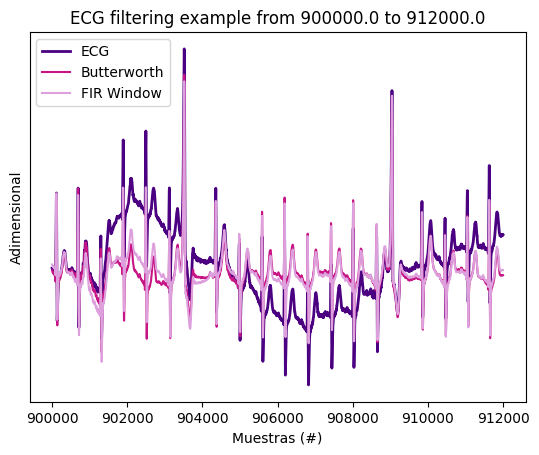

In [27]:
#%% Cargar ECG

fs_ecg = 1000  # Hz

#################
# ECG con ruido
#################

# Para listar las variables que hay en el archivo
# sio.whosmat('ECG_TP4.mat')

mat_struct = sio.loadmat('ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead'].flatten()

cant_muestras = len(ecg_one_lead)

print("")
print("INFORMACION ECG")
print("--------------------------------")
print("Cantidad de muestras:", cant_muestras)
print("Frecuencia de muestreo ECG:", fs_ecg, "Hz")
print("--------------------------------")


#%% Procesar el ECG

# Butterworth con filtfilt: no queda corrido porque filtra ida y vuelta
ECG_f_butt = sig.sosfiltfilt(sos_but, ecg_one_lead)

# FIR Window con lfilter: queda demorado porque es causal
ECG_f_wh = sig.lfilter(b_win, 1, ecg_one_lead)

# Demora del FIR
# Para FIR de fase lineal: demora = (numtaps - 1)/2
demora = int((numtaps - 1) / 2)


###################################
#%% Regiones de interes con ruido #
###################################

regs_interes = (
        [4000, 5500],     # muestras
        [10e3, 11e3],     # muestras
        )

for ii in regs_interes:

    zoom_region = np.arange(
        np.max([0, ii[0]]),
        np.min([cant_muestras - demora, ii[1]]),
        dtype='uint'
    )

    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], color='mediumpurple' , label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_butt[zoom_region], color='deeppink' , label='Butterworth')
    plt.plot(zoom_region, ECG_f_wh[zoom_region + demora], color='darkred' ,label='FIR Window')

    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]))
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')

    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())

    plt.show()


###################################
#%% Regiones de interes sin ruido #
###################################

regs_interes = (
        np.array([5, 5.2]) * 60 * fs_ecg,     # minutos a muestras
        np.array([12, 12.4]) * 60 * fs_ecg,   # minutos a muestras
        np.array([15, 15.2]) * 60 * fs_ecg,   # minutos a muestras
        )

for ii in regs_interes:

    zoom_region = np.arange(
        np.max([0, ii[0]]),
        np.min([cant_muestras - demora, ii[1]]),   
        dtype='uint'
    )

    plt.figure()
    plt.plot(zoom_region, ecg_one_lead[zoom_region], color='indigo' , label='ECG', linewidth=2)
    plt.plot(zoom_region, ECG_f_butt[zoom_region], color='mediumvioletred' , label='Butterworth')
    plt.plot(zoom_region, ECG_f_wh[zoom_region + demora], color='plum' , label='FIR Window')

    plt.title('ECG filtering example from ' + str(ii[0]) + ' to ' + str(ii[1]))
    plt.ylabel('Adimensional')
    plt.xlabel('Muestras (#)')

    axes_hdl = plt.gca()
    axes_hdl.legend()
    axes_hdl.set_yticks(())

    plt.show()